**IMPLEMENTING AND COMPARING BLACK-SCHOLES FORMULA ON GOLDMAN SACHS OPTIONS**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    call_price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return call_price

In [3]:
gs = yf.Ticker('GS')
expirations = gs.options
print(expirations[:10])

('2026-08-28', '2026-09-04', '2026-09-11', '2026-09-18', '2026-09-25', '2026-10-02', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15')


In [4]:
opt_chain = gs.option_chain('2026-11-20')
calls = opt_chain.calls
puts = opt_chain.puts

print(calls.head())
print(calls.columns.tolist())

      contractSymbol             lastTradeDate  strike  lastPrice  bid  ask  \
0  GS261120C00400000 2026-08-03 19:20:31+00:00   400.0     621.28  0.0  0.0   
1  GS261120C00430000 2026-08-03 19:21:32+00:00   430.0     591.75  0.0  0.0   
2  GS261120C00450000 2026-08-03 19:49:17+00:00   450.0     574.42  0.0  0.0   
3  GS261120C00460000 2026-08-03 19:23:14+00:00   460.0     561.63  0.0  0.0   
4  GS261120C00470000 2026-08-25 13:30:02+00:00   470.0     579.05  0.0  0.0   

   change  percentChange  volume  openInterest  impliedVolatility  inTheMoney  \
0     0.0            0.0     NaN             0            0.00001        True   
1     0.0            0.0     NaN             0            0.00001        True   
2     0.0            0.0     2.0             0            0.00001        True   
3     0.0            0.0     NaN             0            0.00001        True   
4     0.0            0.0     1.0             0            0.00001        True   

  contractSize currency  
0      REGUL

In [5]:
current_price = gs.history(period='1d')['Close'].iloc[-1]
print(current_price)

1040.8699951171875


In [16]:
from datetime import datetime

today = datetime.now()
expiry = datetime(2026, 11, 20)
T = (expiry - today).days / 365
print(T)

0.2273972602739726


In [18]:
from scipy.optimize import brentq

def implied_vol_objective(sigma, S, K, T, r, market_price):
    return black_scholes_call(S, K, T, r, sigma) - market_price

implied_vol_calculated = brentq(implied_vol_objective, 0.01, 3.0, args=(current_price, 1040, T, 0.05, 78.00))
print(implied_vol_calculated)

0.36379131148334615


In [20]:
theoretical_price_corrected = black_scholes_call(S=current_price, K=1040, T=T, r=0.05, sigma=implied_vol_calculated)
print(f"Black-Scholes (corrected): ${theoretical_price_corrected:.2f}")
print(f"Actual market price: $78.00")

Black-Scholes (corrected): $78.00
Actual market price: $78.00


**THE GREEKS**

In [21]:
def calculate_greeks(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100

    return delta, gamma, theta, vega

In [24]:
the_greeks = calculate_greeks(S=current_price,K=1040,T=T,r=0.05,sigma=implied_vol_calculated)
print(f"The greek values delta, gamma, theta and vega are:{the_greeks}")

The greek values delta, gamma, theta and vega are:(np.float64(0.5624169016832532), np.float64(0.002182274464025356), np.float64(-0.49813879330293515), np.float64(1.9558696158396844))


**VISUALISATION**

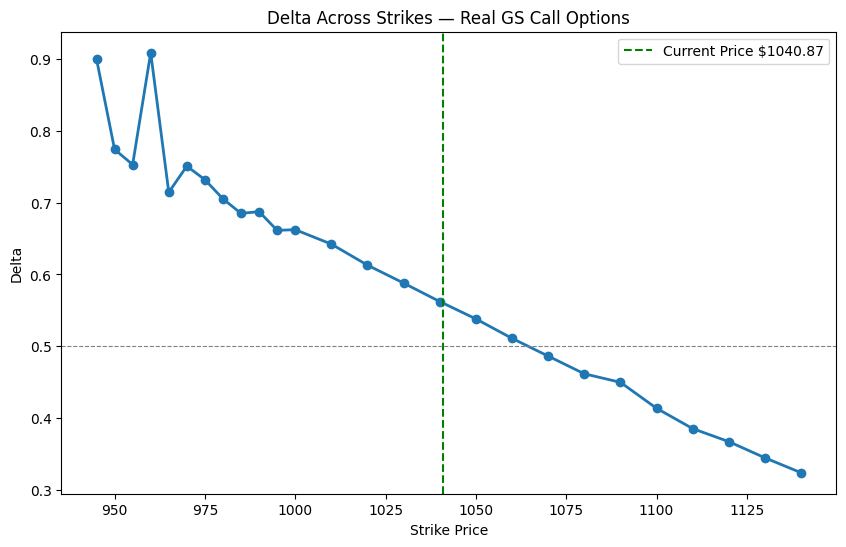

In [25]:
strikes_list = []
deltas_list = []

for idx, row in calls_near_money.iterrows():
    K = row['strike']
    market_price = row['lastPrice']
    try:
        iv = brentq(implied_vol_objective, 0.01, 3.0, args=(current_price, K, T, 0.05, market_price))
        delta, _, _, _ = calculate_greeks(current_price, K, T, 0.05, iv)
        strikes_list.append(K)
        deltas_list.append(delta)
    except:
        continue

plt.figure(figsize=(10,6))
plt.plot(strikes_list, deltas_list, marker='o', linewidth=2)
plt.axvline(x=current_price, color='green', linestyle='--', label=f'Current Price ${current_price:.2f}')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Strike Price')
plt.ylabel('Delta')
plt.title('Delta Across Strikes — Real GS Call Options')
plt.legend()
plt.show()